# Modulo 4: CNN de clasificacion con ResNet

Este Notebook entrena y evalua la CNN sobre los mosaicos temporales generados


## Librerias y parametros del entrenamiento


In [51]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader
from torchinfo import summary
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode

PROJECT_ROOT = Path.cwd().parent

MANIFEST_PATH = PROJECT_ROOT / "outputs" / "person_windows" / "person_window_manifest.csv"
TRAINING_MANIFEST_OUTPUT_PATH = PROJECT_ROOT / "outputs" / "person_windows" / "person_window_manifest_cnn.csv"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "models"
METRICS_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"

RANDOM_SEED = 21
IMAGE_SIZE = 224
NUM_WORKERS = 0
DEVICE_NAME = "auto"

LABEL_TO_INDEX = {"normal": 0, "hurto_simulado": 1}
INDEX_TO_LABEL = {value: key for key, value in LABEL_TO_INDEX.items()}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

pd.Series(
    {
        "MANIFEST_PATH": str(MANIFEST_PATH),
        "TRAINING_MANIFEST_OUTPUT_PATH": str(TRAINING_MANIFEST_OUTPUT_PATH),
        "IMAGE_SIZE": IMAGE_SIZE,
        "NUM_WORKERS": NUM_WORKERS,
        "DEVICE_NAME": DEVICE_NAME,
    }
)


MANIFEST_PATH                    c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
TRAINING_MANIFEST_OUTPUT_PATH    c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
IMAGE_SIZE                                                                     224
NUM_WORKERS                                                                      0
DEVICE_NAME                                                                   auto
dtype: object

## Manifest de mosaicos y distribucion por split


In [52]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df = manifest_df[manifest_df["mosaic_path"].notna()].copy()
manifest_df = manifest_df[manifest_df["mosaic_path"].astype(str) != ""].copy()
if "valid_sample" in manifest_df.columns:
    manifest_df = manifest_df[manifest_df["valid_sample"].astype(str).str.lower() == "true"].copy()
label_column = "source_label" if "source_label" in manifest_df.columns else "class_name"
manifest_df["label_name"] = manifest_df[label_column].astype(str)
manifest_df = manifest_df[manifest_df["label_name"].isin(LABEL_TO_INDEX)].copy()
manifest_df["label_index"] = manifest_df["label_name"].map(LABEL_TO_INDEX).astype(int)
training_manifest_df = manifest_df.sort_values(["split", "sample_id"]).reset_index(drop=True)

training_manifest_df.to_csv(TRAINING_MANIFEST_OUTPUT_PATH, index=False)

split_summary_df = (
    training_manifest_df.groupby(["split", "label_name"])
    .size()
    .reset_index(name="num_samples")
    .sort_values(["split", "label_name"])
    .reset_index(drop=True)
)
split_summary_df


,split,label_name,num_samples
0,test,hurto_simulado,16
1,test,normal,34
2,train,hurto_simulado,61
3,train,normal,89
4,val,hurto_simulado,18
5,val,normal,25


## Transformaciones y registros por split


In [53]:
train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_records = (
    training_manifest_df[training_manifest_df["split"] == "train"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)
val_records = (
    training_manifest_df[training_manifest_df["split"] == "val"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)
test_records = (
    training_manifest_df[training_manifest_df["split"] == "test"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)

print(f"Train records: {len(train_records)}")
print(f"Val records: {len(val_records)}")
print(f"Test records: {len(test_records)}")

Train records: 150
Val records: 43
Test records: 50


## Un mosaico de referencia


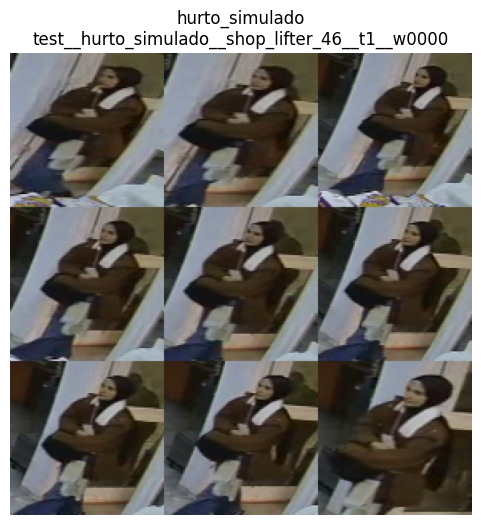

In [54]:
preview_row = training_manifest_df.sort_values(["label_name", "sample_id"]).iloc[0]
preview_path = PROJECT_ROOT / Path(str(preview_row["mosaic_path"]))

with Image.open(preview_path) as preview_image:
    plt.figure(figsize=(6, 6))
    plt.imshow(preview_image.convert("RGB"))
    plt.title(f"{preview_row['label_name']}\n{preview_row['sample_id']}")
    plt.axis("off")
    plt.show()

## Carga de lotes


In [55]:
device = torch.device("cuda" if DEVICE_NAME == "auto" and torch.cuda.is_available() else DEVICE_NAME if DEVICE_NAME != "auto" else "cpu")
pd.Series({"device": str(device), "cuda_available": torch.cuda.is_available()})


device              cpu
cuda_available    False
dtype: object

## Configuraciones de modelos


In [56]:
MODEL_CONFIGS = {
    "modelo_1": {
        "description": "Base comparable: ResNet-50 preentrenada, cabeza primero y fine-tuning de layer4.",
        "batch_size": 8,
        "total_epochs": 15,
        "head_epochs": 5,
        "lr_head": 1e-3,
        "lr_finetune": 1e-4,
        "weight_decay": 1e-4,
        "dropout": 0.30,
        "pretrained": True,
        "freeze_backbone": True,
        "unfreeze_layer4": True,
        "early_stopping": True,
        "early_stopping_patience": 4,
    },
    "modelo_2": {
        "description": "Mas regularizado: busca reducir sobreajuste con mas dropout, mas weight decay y LR menor.",
        "batch_size": 8,
        "total_epochs": 15,
        "head_epochs": 5,
        "lr_head": 7.5e-4,
        "lr_finetune": 5e-5,
        "weight_decay": 5e-4,
        "dropout": 0.50,
        "pretrained": True,
        "freeze_backbone": True,
        "unfreeze_layer4": True,
        "early_stopping": True,
        "early_stopping_patience": 5,
    },
}

pd.DataFrame.from_dict(MODEL_CONFIGS, orient="index")


,description,batch_size,total_epochs,head_epochs,lr_head,lr_finetune,weight_decay,dropout,pretrained,freeze_backbone,unfreeze_layer4,early_stopping,early_stopping_patience
modelo_1,"Base comparable: ResNet-50 preentrenada, cabez...",8,15,5,0.00100,0.00010,0.0001,0.3,True,True,True,True,4
modelo_2,Mas regularizado: busca reducir sobreajuste co...,8,15,5,0.00075,0.00005,0.0005,0.5,True,True,True,True,5


## Funciones de entrenamiento y evaluacion


In [57]:
all_model_results = []


def build_artifact_paths(model_run_name: str) -> dict[str, Path]:
    return {
        "best_model": MODEL_OUTPUT_DIR / f"{model_run_name}_best_model.pt",
        "last_model": MODEL_OUTPUT_DIR / f"{model_run_name}_last_model.pt",
        "train_history": METRICS_OUTPUT_DIR / f"{model_run_name}_train_history.csv",
        "test_metrics": METRICS_OUTPUT_DIR / f"{model_run_name}_test_metrics.json",
        "confusion_matrix_csv": METRICS_OUTPUT_DIR / f"{model_run_name}_confusion_matrix.csv",
        "loss_curve": FIGURES_OUTPUT_DIR / f"{model_run_name}_loss_curve.png",
        "confusion_matrix_png": FIGURES_OUTPUT_DIR / f"{model_run_name}_confusion_matrix.png",
    }


def make_data_loaders(config: dict[str, object]) -> tuple[DataLoader, DataLoader, DataLoader]:
    batch_size = int(config["batch_size"])
    train_loader = DataLoader(
        train_records,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_records,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_records,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader


def build_model(config: dict[str, object]) -> torch.nn.Module:
    weights = ResNet50_Weights.DEFAULT if bool(config["pretrained"]) else None
    model = resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=float(config["dropout"])),
        nn.Linear(in_features, 2),
    )

    if bool(config["freeze_backbone"]):
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    return model.to(device)


def set_trainable_phase(model: torch.nn.Module, phase_name: str, config: dict[str, object]) -> None:
    if phase_name == "head":
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
    elif phase_name == "finetune":
        if bool(config["unfreeze_layer4"]):
            for parameter in model.parameters():
                parameter.requires_grad = False
            for parameter in model.layer4.parameters():
                parameter.requires_grad = True
            for parameter in model.fc.parameters():
                parameter.requires_grad = True
        else:
            for parameter in model.parameters():
                parameter.requires_grad = True


def load_batch_images(batch: dict[str, object], transform: transforms.Compose) -> torch.Tensor:
    images = []
    for mosaic_path in batch["mosaic_path"]:
        with Image.open(PROJECT_ROOT / Path(str(mosaic_path))) as image:
            images.append(transform(image.convert("RGB")))
    return torch.stack(images).to(device)


def binary_metrics(y_true: list[int], y_pred: list[int]) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)) if y_true else 0.0,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)) if y_true else 0.0,
        "recall": float(recall_score(y_true, y_pred, zero_division=0)) if y_true else 0.0,
        "f1": float(f1_score(y_true, y_pred, zero_division=0)) if y_true else 0.0,
    }


def train_one_model(model_run_name: str, config: dict[str, object]) -> tuple[pd.DataFrame, dict[str, Path]]:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    paths = build_artifact_paths(model_run_name)
    train_loader, val_loader, _test_loader = make_data_loaders(config)
    model = build_model(config)
    criterion = nn.CrossEntropyLoss()
    history_rows = []
    best_val_loss = float("inf")
    patience_counter = 0
    global_epoch = 0

    total_epochs = int(config["total_epochs"])
    head_epochs = min(int(config["head_epochs"]), total_epochs)
    phases = [{"phase_name": "head", "epochs": head_epochs, "lr": float(config["lr_head"])}]
    finetune_epochs = max(total_epochs - head_epochs, 0)
    if finetune_epochs > 0:
        phases.append({"phase_name": "finetune", "epochs": finetune_epochs, "lr": float(config["lr_finetune"])})

    print(f"Entrenando {model_run_name}")
    print(f"Parametros entrenables iniciales: {sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)}")

    for phase in phases:
        phase_name = str(phase["phase_name"])
        set_trainable_phase(model, phase_name, config)
        optimizer = torch.optim.Adam(
            [parameter for parameter in model.parameters() if parameter.requires_grad],
            lr=float(phase["lr"]),
            weight_decay=float(config["weight_decay"]),
        )

        for phase_epoch in range(1, int(phase["epochs"]) + 1):
            global_epoch += 1
            model.train()
            train_losses = []
            train_true = []
            train_pred = []

            for batch in train_loader:
                images = load_batch_images(batch, train_transform)
                labels = batch["label_index"].to(device)

                optimizer.zero_grad()
                logits = model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

                train_losses.append(float(loss.detach().cpu().item()))
                train_true.extend(labels.detach().cpu().tolist())
                train_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

            model.eval()
            val_losses = []
            val_true = []
            val_pred = []

            with torch.no_grad():
                for batch in val_loader:
                    images = load_batch_images(batch, eval_transform)
                    labels = batch["label_index"].to(device)
                    logits = model(images)
                    loss = criterion(logits, labels)

                    val_losses.append(float(loss.detach().cpu().item()))
                    val_true.extend(labels.detach().cpu().tolist())
                    val_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

            train_loss = float(np.mean(train_losses)) if train_losses else 0.0
            val_loss = float(np.mean(val_losses)) if val_losses else 0.0
            train_metric_values = binary_metrics(train_true, train_pred)
            val_metric_values = binary_metrics(val_true, val_pred)

            history_rows.append(
                {
                    "model_run_name": model_run_name,
                    "global_epoch": global_epoch,
                    "phase_name": phase_name,
                    "phase_epoch": phase_epoch,
                    "learning_rate": float(phase["lr"]),
                    "trainable_params": sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad),
                    "train_loss": train_loss,
                    "train_accuracy": train_metric_values["accuracy"],
                    "train_precision": train_metric_values["precision"],
                    "train_recall": train_metric_values["recall"],
                    "train_f1": train_metric_values["f1"],
                    "val_loss": val_loss,
                    "val_accuracy": val_metric_values["accuracy"],
                    "val_precision": val_metric_values["precision"],
                    "val_recall": val_metric_values["recall"],
                    "val_f1": val_metric_values["f1"],
                }
            )

            checkpoint = {
                "model_run_name": model_run_name,
                "model_state_dict": model.state_dict(),
                "epoch": global_epoch,
                "phase_name": phase_name,
                "val_metrics": {
                    "accuracy": val_metric_values["accuracy"],
                    "precision": val_metric_values["precision"],
                    "recall": val_metric_values["recall"],
                    "f1": val_metric_values["f1"],
                    "loss": val_loss,
                },
                "index_to_class": INDEX_TO_LABEL,
                "class_to_index": LABEL_TO_INDEX,
                "training_setup": {
                    "manifest_path": str(TRAINING_MANIFEST_OUTPUT_PATH),
                    "model_run_name": model_run_name,
                    "image_size": IMAGE_SIZE,
                    **config,
                },
            }
            torch.save(checkpoint, paths["last_model"])

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(checkpoint, paths["best_model"])
            else:
                patience_counter += 1

            print(
                f"{model_run_name} | Epoch {global_epoch:02d} | phase={phase_name} | "
                f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_metric_values['f1']:.4f}"
            )

            if bool(config["early_stopping"]) and patience_counter >= int(config["early_stopping_patience"]):
                print(f"Early stopping activado para {model_run_name}.")
                break

        if bool(config["early_stopping"]) and patience_counter >= int(config["early_stopping_patience"]):
            break

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(paths["train_history"], index=False)
    return history_df, paths


def plot_loss_curve(history_df: pd.DataFrame, model_run_name: str, paths: dict[str, Path]) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["global_epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["global_epoch"], history_df["val_loss"], marker="o", label="Val loss")
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.title(f"Curva de loss ResNet-50 TL - {model_run_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(paths["loss_curve"], dpi=150)
    plt.show()


def evaluate_one_model(model_run_name: str, config: dict[str, object], paths: dict[str, Path]) -> dict[str, object]:
    _train_loader, _val_loader, test_loader = make_data_loaders(config)
    checkpoint_data = torch.load(paths["best_model"], map_location=device)
    eval_model = resnet50(weights=None)
    in_features = eval_model.fc.in_features
    eval_model.fc = nn.Sequential(
        nn.Dropout(p=float(config["dropout"])),
        nn.Linear(in_features, 2),
    )
    eval_model.load_state_dict(checkpoint_data["model_state_dict"])
    eval_model = eval_model.to(device)
    eval_model.eval()

    test_true = []
    test_pred = []

    with torch.no_grad():
        for batch in test_loader:
            images = load_batch_images(batch, eval_transform)
            labels = batch["label_index"].to(device)
            logits = eval_model(images)
            predictions = torch.argmax(logits, dim=1)
            test_true.extend(labels.detach().cpu().tolist())
            test_pred.extend(predictions.detach().cpu().tolist())

    test_metric_values = binary_metrics(test_true, test_pred)
    test_confusion = confusion_matrix(test_true, test_pred, labels=[0, 1]) if test_true else np.zeros((2, 2), dtype=int)
    confusion_df = pd.DataFrame(
        test_confusion,
        index=[f"real_{INDEX_TO_LABEL[0]}", f"real_{INDEX_TO_LABEL[1]}"],
        columns=[f"pred_{INDEX_TO_LABEL[0]}", f"pred_{INDEX_TO_LABEL[1]}"],
    )
    confusion_df.to_csv(paths["confusion_matrix_csv"])

    test_metrics = {
        "model_run_name": model_run_name,
        **test_metric_values,
        "num_test_samples": int(len(test_true)),
        "model_path": str(paths["best_model"]),
        "last_model_path": str(paths["last_model"]),
        "train_history_path": str(paths["train_history"]),
        "confusion_matrix_csv_path": str(paths["confusion_matrix_csv"]),
        "loss_curve_path": str(paths["loss_curve"]),
        "confusion_matrix_png_path": str(paths["confusion_matrix_png"]),
        "best_val_metrics": checkpoint_data.get("val_metrics", {}),
        "config": config,
    }
    paths["test_metrics"].write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")

    plt.figure(figsize=(6, 5))
    plt.imshow(test_confusion, cmap="Blues")
    plt.title(f"Matriz de confusion CNN ResNet TL - {model_run_name}")
    plt.colorbar()
    plt.xticks([0, 1], [INDEX_TO_LABEL[0], INDEX_TO_LABEL[1]], rotation=15)
    plt.yticks([0, 1], [INDEX_TO_LABEL[0], INDEX_TO_LABEL[1]])
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    for row_index in range(test_confusion.shape[0]):
        for col_index in range(test_confusion.shape[1]):
            plt.text(
                col_index,
                row_index,
                str(int(test_confusion[row_index, col_index])),
                ha="center",
                va="center",
                color="black",
            )
    plt.tight_layout()
    plt.savefig(paths["confusion_matrix_png"], dpi=150)
    plt.show()

    return test_metrics


def run_model_experiment(model_run_name: str, config: dict[str, object]) -> dict[str, object]:
    history_df, paths = train_one_model(model_run_name, config)
    plot_loss_curve(history_df, model_run_name, paths)
    test_metrics = evaluate_one_model(model_run_name, config, paths)
    result_summary = {
        "model_run_name": model_run_name,
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "best_val_loss": test_metrics["best_val_metrics"].get("loss"),
        "best_val_f1": test_metrics["best_val_metrics"].get("f1"),
    }
    all_model_results.append(result_summary)
    return result_summary


## Construccion y entrenamiento: modelo_1


Entrenando modelo_1
Parametros entrenables iniciales: 4098
modelo_1 | Epoch 01 | phase=head | train_loss=0.6541 | val_loss=0.5593 | val_f1=0.6667
modelo_1 | Epoch 02 | phase=head | train_loss=0.5503 | val_loss=0.5021 | val_f1=0.6667
modelo_1 | Epoch 03 | phase=head | train_loss=0.4600 | val_loss=0.4837 | val_f1=0.6154
modelo_1 | Epoch 04 | phase=head | train_loss=0.4631 | val_loss=0.4572 | val_f1=0.6897
modelo_1 | Epoch 05 | phase=head | train_loss=0.4007 | val_loss=0.4202 | val_f1=0.7143
modelo_1 | Epoch 06 | phase=finetune | train_loss=0.4145 | val_loss=0.3380 | val_f1=0.8750
modelo_1 | Epoch 07 | phase=finetune | train_loss=0.2929 | val_loss=0.3176 | val_f1=0.8000
modelo_1 | Epoch 08 | phase=finetune | train_loss=0.2001 | val_loss=0.2786 | val_f1=0.8387
modelo_1 | Epoch 09 | phase=finetune | train_loss=0.1479 | val_loss=0.2931 | val_f1=0.8000
modelo_1 | Epoch 10 | phase=finetune | train_loss=0.1377 | val_loss=0.2411 | val_f1=0.9091
modelo_1 | Epoch 11 | phase=finetune | train_loss=0

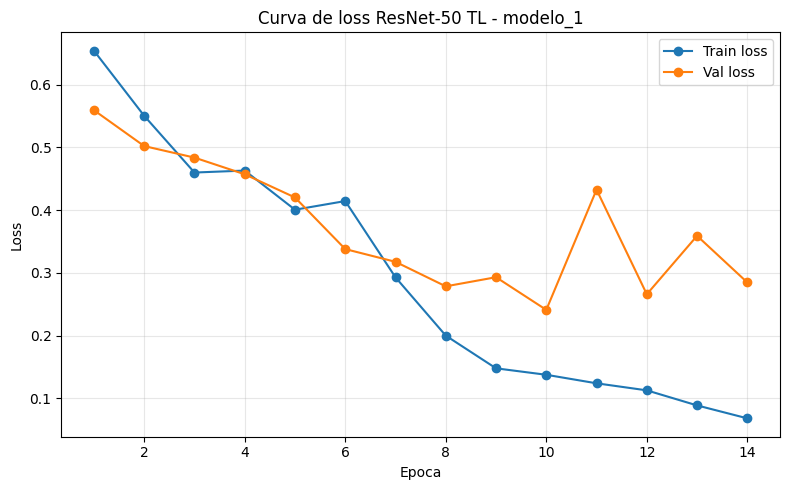

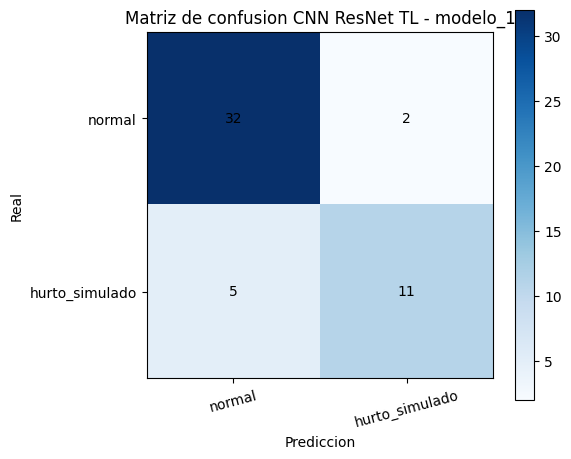

model_run_name    modelo_1
accuracy              0.86
precision         0.846154
recall              0.6875
f1                0.758621
best_val_loss     0.241109
best_val_f1       0.909091
dtype: object

In [58]:
modelo_1_result = run_model_experiment("modelo_1", MODEL_CONFIGS["modelo_1"])
pd.Series(modelo_1_result)


## Construccion y entrenamiento: modelo_2


Entrenando modelo_2
Parametros entrenables iniciales: 4098
modelo_2 | Epoch 01 | phase=head | train_loss=0.6759 | val_loss=0.5781 | val_f1=0.2000
modelo_2 | Epoch 02 | phase=head | train_loss=0.5759 | val_loss=0.5469 | val_f1=0.6154
modelo_2 | Epoch 03 | phase=head | train_loss=0.5099 | val_loss=0.5237 | val_f1=0.5600
modelo_2 | Epoch 04 | phase=head | train_loss=0.5048 | val_loss=0.4963 | val_f1=0.5000
modelo_2 | Epoch 05 | phase=head | train_loss=0.4465 | val_loss=0.4561 | val_f1=0.6667
modelo_2 | Epoch 06 | phase=finetune | train_loss=0.4572 | val_loss=0.4178 | val_f1=0.8387
modelo_2 | Epoch 07 | phase=finetune | train_loss=0.3741 | val_loss=0.4024 | val_f1=0.7586
modelo_2 | Epoch 08 | phase=finetune | train_loss=0.3218 | val_loss=0.3532 | val_f1=0.8387
modelo_2 | Epoch 09 | phase=finetune | train_loss=0.2848 | val_loss=0.3651 | val_f1=0.7586
modelo_2 | Epoch 10 | phase=finetune | train_loss=0.2743 | val_loss=0.3641 | val_f1=0.8387
modelo_2 | Epoch 11 | phase=finetune | train_loss=0

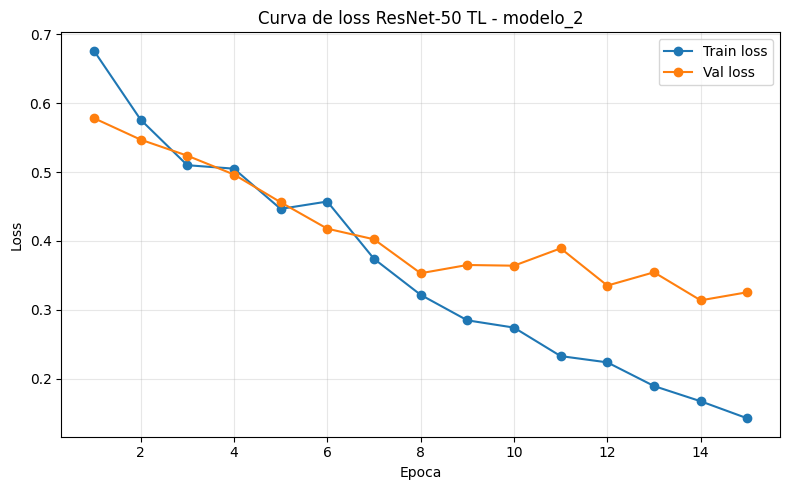

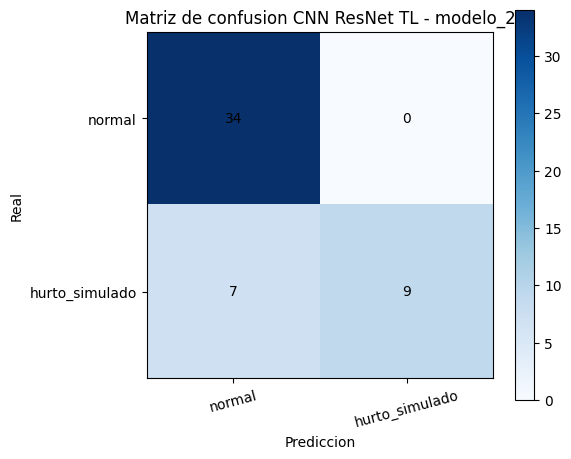

model_run_name    modelo_2
accuracy              0.86
precision              1.0
recall              0.5625
f1                    0.72
best_val_loss     0.313839
best_val_f1       0.848485
dtype: object

In [59]:
modelo_2_result = run_model_experiment("modelo_2", MODEL_CONFIGS["modelo_2"])
pd.Series(modelo_2_result)


## Comparacion final de modelos


In [60]:
comparison_rows = []
for model_run_name in MODEL_CONFIGS:
    metrics_path = build_artifact_paths(model_run_name)["test_metrics"]
    test_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    comparison_rows.append(
        {
            "model_run_name": model_run_name,
            "accuracy": test_metrics["accuracy"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "best_val_loss": test_metrics["best_val_metrics"].get("loss"),
            "best_val_f1": test_metrics["best_val_metrics"].get("f1"),
        }
    )

model_result_summary_df = pd.DataFrame(comparison_rows)

COMPARISON_METRICS_PATH = METRICS_OUTPUT_DIR / "modelos_comparacion_metricas.csv"
model_result_summary_df.to_csv(COMPARISON_METRICS_PATH, index=False)
model_result_summary_df


,model_run_name,accuracy,precision,recall,f1,best_val_loss,best_val_f1
0,modelo_1,0.86,0.846154,0.6875,0.758621,0.241109,0.909091
1,modelo_2,0.86,1.000000,0.5625,0.720000,0.313839,0.848485


## Summary de mejores modelos


In [61]:
def load_best_model_for_summary(model_run_name: str) -> torch.nn.Module:
    config = MODEL_CONFIGS[model_run_name]
    paths = build_artifact_paths(model_run_name)
    checkpoint_data = torch.load(paths["best_model"], map_location=device)

    model = resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=float(config["dropout"])),
        nn.Linear(in_features, 2),
    )
    model.load_state_dict(checkpoint_data["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model



### Summary mejor modelo_1


In [62]:
modelo_1_best_model = load_best_model_for_summary("modelo_1")
summary(modelo_1_best_model, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE), device=device)


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 2]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

### Summary mejor modelo_2


In [63]:
modelo_2_best_model = load_best_model_for_summary("modelo_2")
summary(modelo_2_best_model, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE), device=device)


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 2]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 